In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
data=pd.read_csv(r"C:\Users\kumar\Downloads\loan_risk_prediction_dataset.csv")

In [3]:
data.head(3)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1


In [4]:
#df.describe()

In [5]:
df=data.copy()

In [6]:
df.isna().sum()

Age                  0
Income             196
LoanAmount           0
CreditScore        194
YearsExperience      0
Gender               0
Education          198
City                 0
EmploymentType       0
LoanApproved         0
dtype: int64

In [7]:
df["EmploymentType"].value_counts()

EmploymentType
Self-Employed    1730
Unemployed       1660
Salaried         1610
Name: count, dtype: int64

In [8]:
df["Income"]=df["Income"].fillna(df["Income"].mean())

In [9]:
df["CreditScore"]=df["CreditScore"].fillna(df["CreditScore"].mean())

In [10]:
df["Education"]=df["Education"].fillna(df["Education"].mode()[0])


In [11]:
df["Income"]=df["Income"].round(1)

In [12]:
df["Gender1"]=df["Gender"].apply(lambda x:1 if x=="Male" else 0)

In [13]:
df.head(10)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved,Gender1
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0,0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0,1
2,46,44219.0,26530.0,781.0,26,Male,PhD,Houston,Self-Employed,1,1
3,32,56307.0,11531.0,549.0,11,Male,Bachelors,New York,Unemployed,0,1
4,60,37034.0,27871.0,500.0,19,Female,High School,Chicago,Unemployed,0,0
5,25,47886.0,18106.0,835.0,13,Male,Masters,New York,Salaried,1,1
6,38,54748.0,25374.0,760.0,9,Female,High School,New York,Self-Employed,1,0
7,56,49738.1,6279.0,599.0,22,Male,PhD,New York,Unemployed,0,1
8,36,25918.0,25041.0,777.0,29,Female,Bachelors,San Francisco,Unemployed,0,0
9,40,43415.0,2065.0,382.0,30,Female,High School,San Francisco,Self-Employed,0,0


In [14]:
from sklearn.preprocessing import OneHotEncoder
one=OneHotEncoder(sparse_output=False)

In [15]:
one.fit(df[["Education"]])

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [16]:
en=one.transform(df[["Education"]])

In [17]:
col=one.get_feature_names_out(["Education"])

In [18]:
col

array(['Education_Bachelors', 'Education_High School',
       'Education_Masters', 'Education_PhD'], dtype=object)

In [19]:
dff=pd.DataFrame(en,columns=col,index=df.index)

In [20]:
df=pd.concat([df,dff],axis=1)

In [21]:
df

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved,Gender1,Education_Bachelors,Education_High School,Education_Masters,Education_PhD
0,56,48353.0,31258.0,675.00000,20,Female,High School,Houston,Unemployed,0,0,0.0,1.0,0.0,0.0
1,69,57462.0,23262.0,586.00000,6,Male,High School,San Francisco,Self-Employed,0,1,0.0,1.0,0.0,0.0
2,46,44219.0,26530.0,781.00000,26,Male,PhD,Houston,Self-Employed,1,1,0.0,0.0,0.0,1.0
3,32,56307.0,11531.0,549.00000,11,Male,Bachelors,New York,Unemployed,0,1,1.0,0.0,0.0,0.0
4,60,37034.0,27871.0,500.00000,19,Female,High School,Chicago,Unemployed,0,0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,24,36780.0,23383.0,575.49459,23,Male,Masters,Houston,Salaried,0,1,0.0,0.0,1.0,0.0
4996,66,99146.0,9760.0,306.00000,14,Male,PhD,New York,Unemployed,0,1,0.0,0.0,0.0,1.0
4997,26,58100.0,18230.0,311.00000,10,Female,High School,San Francisco,Self-Employed,0,0,0.0,1.0,0.0,0.0
4998,53,58513.0,12373.0,813.00000,23,Male,PhD,Houston,Salaried,1,1,0.0,0.0,0.0,1.0


In [22]:
one1=OneHotEncoder(sparse_output=False)

In [23]:
one1.fit(df[["EmploymentType"]])

,categories,'auto'
,drop,None
,sparse_output,False
,dtype,<class 'numpy.float64'>
,handle_unknown,'error'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [24]:
en1=one1.transform(df[["EmploymentType"]])

In [25]:
col1=one1.get_feature_names_out(["EmploymentType"])

In [26]:
dff1=pd.DataFrame(en1,columns=col1,index=df.index)

In [27]:
df=pd.concat([df,dff1],axis=1)

In [28]:
df.head(2)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved,Gender1,Education_Bachelors,Education_High School,Education_Masters,Education_PhD,EmploymentType_Salaried,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0


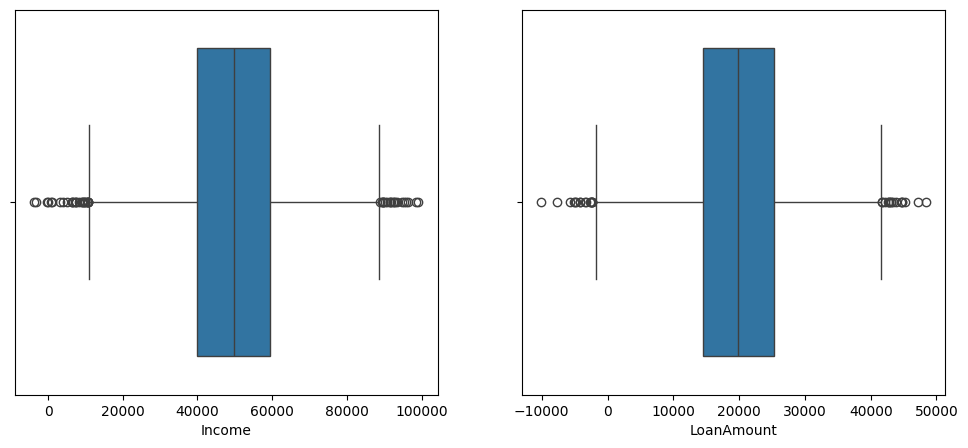

In [29]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.boxplot(x=df["Income"],data=df)

plt.subplot(1,2,2)
sns.boxplot(x=df["LoanAmount"],data=df)
plt.show()

In [30]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved',
       'Gender1', 'Education_Bachelors', 'Education_High School',
       'Education_Masters', 'Education_PhD', 'EmploymentType_Salaried',
       'EmploymentType_Self-Employed', 'EmploymentType_Unemployed'],
      dtype='object')

In [31]:
df.shape

(5000, 18)

In [32]:
q1=df["Income"].quantile(0.25)
q3=df["Income"].quantile(0.75)

In [33]:
IQR=q3-q1
min=q1-(IQR*1.5)
max=q3+(IQR*1.5)

In [34]:
min,max

(np.float64(10805.125), np.float64(88632.125))

In [35]:
q10=df["LoanAmount"].quantile(0.25)
q30=df["LoanAmount"].quantile(0.75)
IQR1=q30-q10
min1=q10-(IQR1*1.5)
max1=q30+(IQR1*1.5)

In [36]:
df.shape

(5000, 18)

In [37]:
df=df[((df["Income"]>min) & (df["Income"]<max))&((df["LoanAmount"]>min1) & (df["LoanAmount"]<max1))]

In [38]:
df.columns

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'YearsExperience',
       'Gender', 'Education', 'City', 'EmploymentType', 'LoanApproved',
       'Gender1', 'Education_Bachelors', 'Education_High School',
       'Education_Masters', 'Education_PhD', 'EmploymentType_Salaried',
       'EmploymentType_Self-Employed', 'EmploymentType_Unemployed'],
      dtype='object')

In [39]:
df.reset_index(inplace=True)

In [40]:
df.head(2)

,index,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved,Gender1,Education_Bachelors,Education_High School,Education_Masters,Education_PhD,EmploymentType_Salaried,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,0,56,48353.0,31258.0,675.0,20,Female,High School,Houston,Unemployed,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1,69,57462.0,23262.0,586.0,6,Male,High School,San Francisco,Self-Employed,0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [41]:
#df=df.drop(columns=["index"])

In [42]:
df

,index,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,LoanApproved,Gender1,Education_Bachelors,Education_High School,Education_Masters,Education_PhD,EmploymentType_Salaried,EmploymentType_Self-Employed,EmploymentType_Unemployed
0,0,56,48353.0,31258.0,675.00000,20,Female,High School,Houston,Unemployed,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
1,1,69,57462.0,23262.0,586.00000,6,Male,High School,San Francisco,Self-Employed,0,1,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,2,46,44219.0,26530.0,781.00000,26,Male,PhD,Houston,Self-Employed,1,1,0.0,0.0,0.0,1.0,0.0,1.0,0.0
3,3,32,56307.0,11531.0,549.00000,11,Male,Bachelors,New York,Unemployed,0,1,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,4,60,37034.0,27871.0,500.00000,19,Female,High School,Chicago,Unemployed,0,0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4916,4994,21,40705.0,15668.0,396.00000,34,Female,Bachelors,Houston,Unemployed,0,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4917,4995,24,36780.0,23383.0,575.49459,23,Male,Masters,Houston,Salaried,0,1,0.0,0.0,1.0,0.0,1.0,0.0,0.0
4918,4997,26,58100.0,18230.0,311.00000,10,Female,High School,San Francisco,Self-Employed,0,0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4919,4998,53,58513.0,12373.0,813.00000,23,Male,PhD,Houston,Salaried,1,1,0.0,0.0,0.0,1.0,1.0,0.0,0.0


In [43]:
#ns.pairplot(data=X,hue="LoanApproved")
#plt.show()

In [44]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
mn=MinMaxScaler()

In [45]:
mn.fit(df[["Age","Income","LoanAmount","CreditScore","YearsExperience"]])

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [46]:
arr=mn.transform(df[["Age","Income","LoanAmount","CreditScore","YearsExperience"]])

In [47]:
dff3=pd.DataFrame(arr,columns=["Age1","Income1","LoanAmount1","CreditScore1","YearsExperience1"],index=df.index)

In [48]:
df=pd.concat([df,dff3],axis=1)

In [49]:
df

,index,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender,Education,City,EmploymentType,...,Education_Masters,Education_PhD,EmploymentType_Salaried,EmploymentType_Self-Employed,EmploymentType_Unemployed,Age1,Income1,LoanAmount1,CreditScore1,YearsExperience1
0,0,56,48353.0,31258.0,675.00000,20,Female,High School,Houston,Unemployed,...,0.0,0.0,0.0,0.0,1.0,0.745098,0.482104,0.763131,0.683060,0.512821
1,1,69,57462.0,23262.0,586.00000,6,Male,High School,San Francisco,Self-Employed,...,0.0,0.0,0.0,1.0,0.0,1.000000,0.599467,0.578278,0.520947,0.153846
2,2,46,44219.0,26530.0,781.00000,26,Male,PhD,Houston,Self-Employed,...,0.0,1.0,0.0,1.0,0.0,0.549020,0.428840,0.653828,0.876138,0.666667
3,3,32,56307.0,11531.0,549.00000,11,Male,Bachelors,New York,Unemployed,...,0.0,0.0,0.0,0.0,1.0,0.274510,0.584585,0.307079,0.453552,0.282051
4,4,60,37034.0,27871.0,500.00000,19,Female,High School,Chicago,Unemployed,...,0.0,0.0,0.0,0.0,1.0,0.823529,0.336267,0.684830,0.364299,0.487179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4916,4994,21,40705.0,15668.0,396.00000,34,Female,Bachelors,Houston,Unemployed,...,0.0,0.0,0.0,0.0,1.0,0.058824,0.383565,0.402719,0.174863,0.871795
4917,4995,24,36780.0,23383.0,575.49459,23,Male,Masters,Houston,Salaried,...,1.0,0.0,1.0,0.0,0.0,0.117647,0.332994,0.581075,0.501812,0.589744
4918,4997,26,58100.0,18230.0,311.00000,10,Female,High School,San Francisco,Self-Employed,...,0.0,0.0,0.0,1.0,0.0,0.156863,0.607687,0.461947,0.020036,0.256410
4919,4998,53,58513.0,12373.0,813.00000,23,Male,PhD,Houston,Salaried,...,0.0,1.0,1.0,0.0,0.0,0.686275,0.613008,0.326544,0.934426,0.589744


In [50]:
x=df[["Age1","Income1","LoanAmount1","CreditScore1","YearsExperience1","Gender1","Education_Bachelors","Education_High School","Education_Masters","Education_PhD","EmploymentType_Salaried","EmploymentType_Self-Employed","EmploymentType_Unemployed"]]
y=df["LoanApproved"]

In [51]:
from sklearn.model_selection import train_test_split

In [52]:
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)

In [53]:
from sklearn.linear_model import LogisticRegression
lg=LogisticRegression()

In [54]:
lg.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [55]:
lg.score(x_test,y_test),lg.score(x_train,y_train)

(0.9045685279187817, 0.8884654471544715)

In [56]:
from sklearn.metrics import confusion_matrix

In [57]:
#cm=confusion_matrix(Y_test,lg2.predict(X_test))
#cm1=confusion_matrix(y_test,lg.predict(x_test))

In [58]:
#plt.figure(figsize=(9,5))
#plt.subplot(1,2,1)
#sns.heatmap(cm,annot=True,fmt="d")
#plt.subplot(1,2,2)


In [59]:
df["CreditScore"]=df["CreditScore"].round(1)

In [60]:
X=df[["Age","Income","LoanAmount","CreditScore","YearsExperience","Gender1","Education_Bachelors","Education_High School","Education_Masters","Education_PhD","EmploymentType_Salaried","EmploymentType_Self-Employed","EmploymentType_Unemployed"]]
Y=df["LoanApproved"]

In [61]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=42,test_size=0.2)

In [62]:
lg2=LogisticRegression()

In [63]:
lg2.fit(X_train,Y_train)


c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [64]:
lg2.score(X_train,Y_train),lg2.score(X_test,Y_test)

(0.804369918699187, 0.8162436548223351)

In [65]:
from sklearn.naive_bayes import BernoulliNB,MultinomialNB,GaussianNB

In [66]:
gs=GaussianNB()

In [67]:
gs.fit(X_train,Y_train)

,priors,None
,var_smoothing,1e-09


In [68]:
gs1=GaussianNB()
gs1.fit(x_train,y_train)
gs1.score(x_train,y_train),gs1.score(x_test,y_test)

(0.8874491869918699, 0.8944162436548223)

In [69]:
gs.score(X_test,Y_test),gs.score(X_train,Y_train)

(0.9299492385786802, 0.9192073170731707)

In [70]:
cm=confusion_matrix(Y_test,gs.predict(X_test))

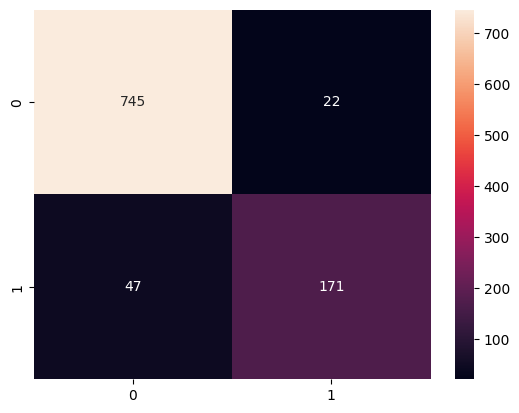

In [71]:
sns.heatmap(cm,annot=True,fmt="d")
plt.show()

In [72]:
br=BernoulliNB()

In [73]:
br.fit(x_train,y_train)
br.score(x_test,y_test),br.score(x_train,y_train)

(0.7786802030456853, 0.7672764227642277)

In [74]:
mt=MultinomialNB()
mt.fit(x_train,y_train)
mt.score(x_test,y_test)

0.7786802030456853

In [75]:
x.shape

(4921, 13)

In [76]:
from sklearn.tree import DecisionTreeClassifier,plot_tree
dc=DecisionTreeClassifier(max_depth=3)
dc.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


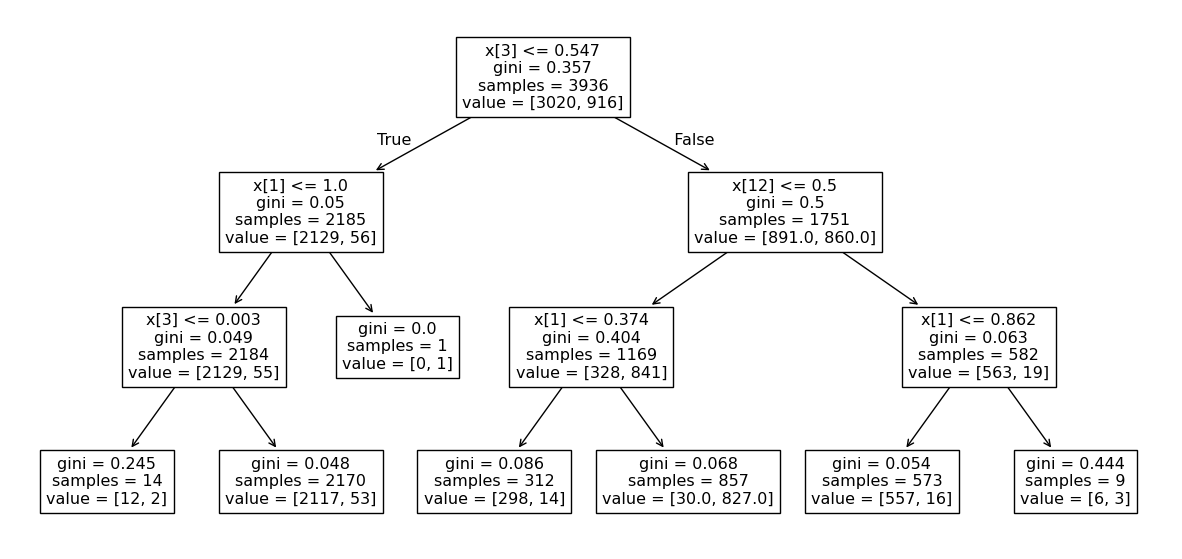

In [77]:
plt.figure(figsize=(15,7))
plot_tree(dc,max_depth=3)
plt.show()

In [78]:
list={"criterion":["gini", "entropy", "log_loss"],"splitter":["best", "random"],"max_depth":[i for i in range(2,21)]}

In [79]:
from sklearn.model_selection import GridSearchCV,RandomizedSearchCV
gd=GridSearchCV(DecisionTreeClassifier(),param_grid=list)

In [80]:
gd.fit(x_train,y_train)

,estimator,DecisionTreeClassifier()
,param_grid,"{'criterion': ['gini', 'entropy', ...], 'max_depth': [2, 3, ...], 'splitter': ['best', 'random']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,None
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'entropy'


In [81]:
gd.best_params_

{'criterion': 'entropy', 'max_depth': 3, 'splitter': 'best'}

In [82]:
gd.best_score_

np.float64(0.9695125097556099)

In [83]:
dc.score(x_test,y_test)*100,dc.score(x_train,y_train)*100

(97.05583756345177, 97.0020325203252)

In [84]:
dc11=DecisionTreeClassifier(max_depth=3)
dc11.fit(X_train,Y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [85]:
dc11.score(X_train,Y_train),dc11.score(X_test,Y_test)

(0.970020325203252, 0.9705583756345177)

In [86]:
from mlxtend.feature_selection import SequentialFeatureSelector
fe=SequentialFeatureSelector(dc,forward=True,k_features=13)

In [87]:
fe.fit(x_train,y_train)

,estimator,DecisionTreeC...r(max_depth=3)
,k_features,"(13, ...)"
,forward,True
,floating,False
,verbose,0
,scoring,'accuracy'
,cv,5
,n_jobs,1
,pre_dispatch,'2*n_jobs'
,clone_estimator,True
,fixed_features,None


In [88]:
fe.k_score_

np.float64(0.9692583801495107)

In [89]:
fe.k_feature_names_

('Age1',
 'Income1',
 'LoanAmount1',
 'CreditScore1',
 'YearsExperience1',
 'Gender1',
 'Education_Bachelors',
 'Education_High School',
 'Education_Masters',
 'Education_PhD',
 'EmploymentType_Salaried',
 'EmploymentType_Self-Employed',
 'EmploymentType_Unemployed')

In [90]:
fe.feature_names

['Age1',
 'Income1',
 'LoanAmount1',
 'CreditScore1',
 'YearsExperience1',
 'Gender1',
 'Education_Bachelors',
 'Education_High School',
 'Education_Masters',
 'Education_PhD',
 'EmploymentType_Salaried',
 'EmploymentType_Self-Employed',
 'EmploymentType_Unemployed']

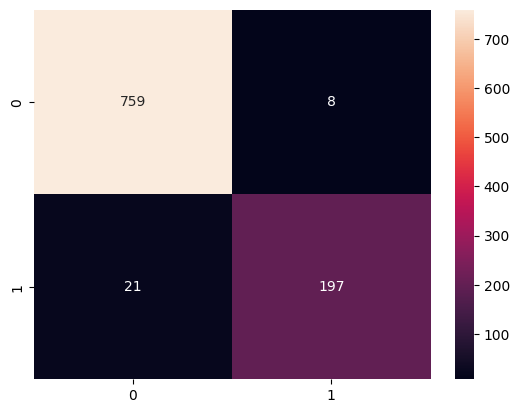

In [91]:
cm=confusion_matrix(y_test,dc.predict(x_test))
sns.heatmap(cm,annot=True,fmt="d")
plt.show()

In [92]:
for i in range(2,21):
    dc1=DecisionTreeClassifier(max_depth=i)
    dc1.fit(x_train,y_train)
    print(dc1.score(x_train,y_train),dc1.score(x_test,y_test)  ,  i)

0.8978658536585366 0.9065989847715736 2
0.970020325203252 0.9705583756345177 3
0.9710365853658537 0.9675126903553299 4
0.9723069105691057 0.9634517766497462 5
0.9735772357723578 0.965482233502538 6
0.975609756097561 0.965482233502538 7
0.979420731707317 0.9543147208121827 8
0.9814532520325203 0.949238578680203 9
0.9839939024390244 0.949238578680203 10
0.9865345528455285 0.9441624365482234 11
0.9878048780487805 0.949238578680203 12
0.9903455284552846 0.9441624365482234 13
0.9933943089430894 0.9380710659898477 14
0.9964430894308943 0.9390862944162437 15
0.9984756097560976 0.9279187817258884 16
0.9994918699186992 0.934010152284264 17
1.0 0.9299492385786802 18
1.0 0.9289340101522843 19
1.0 0.9248730964467005 20


In [93]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)

In [94]:
knn.fit(x_train,y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [95]:
knn.score(x_test,y_test)

0.9005076142131979

In [96]:
from sklearn.svm import SVC
svm=SVC(kernel='poly')

In [97]:
svm.fit(x_train,y_train)

,C,1.0
,kernel,'poly'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [98]:
svm.score(x_test,y_test),svm.score(x_train,y_train)

(0.9289340101522843, 0.9324186991869918)

In [99]:
Y_test.tail(5)

4640    0
3626    1
378     0
495     0
1807    0
Name: LoanApproved, dtype: int64

In [100]:
X_test.tail(5)

,Age,Income,LoanAmount,CreditScore,YearsExperience,Gender1,Education_Bachelors,Education_High School,Education_Masters,Education_PhD,EmploymentType_Salaried,EmploymentType_Self-Employed,EmploymentType_Unemployed
4640,29,21951.0,11812.0,544.0,3,1,0.0,1.0,0.0,0.0,0.0,0.0,1.0
3626,39,88124.0,34719.0,628.0,14,0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
378,54,43788.0,26022.0,304.0,19,0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
495,46,48371.0,32251.0,428.0,0,0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1807,30,79263.0,5512.0,688.0,14,0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


# final model using decision tree which gives 97.05 accurency

In [101]:
#a=float(input("Enter Age:"))
#b=float(input("Enter income:"))
#c=float(input("Enter loanamount:"))
#d=float(input("Enter CreditScore:"))
#e=float(input("Enter YearsExperience:"))
#f=int(input("Enter Gender1:"))
#g=float(input("Enter Education_Bachelors:"))
#h=float(input("Enter Education_High School:"))
#i=float(input("Enter Education_Masters:"))
#j=float(input("Enter Education_PhD:"))
#k=float(input("Enter EmploymentType_Salaried:"))
#l=float(input("Enter EmploymentType_Self-Employed:"))
#m=float(input("Enter EmploymentType_Unemployed"))
#x1=dc11.predict([[a,b,c,d,e,f,g,h,i,j,k,l,m]])


In [102]:
#if(x1==0):
    #print("Loan cannot be approved")
#else:
    #print("97 % chance of loan approved")

In [103]:
cm10=confusion_matrix(Y_test,gs.predict(X_test))
cm2=confusion_matrix(y_test,svm.predict(x_test))
cm3=confusion_matrix(y_test,dc.predict(x_test))

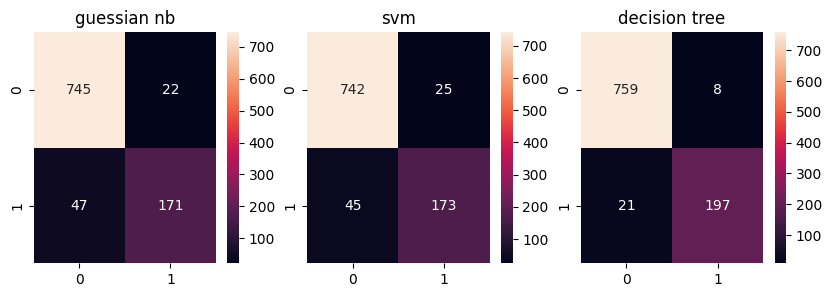

In [104]:
plt.figure(figsize=(10,3))
plt.subplot(1,3,1)
sns.heatmap(cm10,annot=True,fmt="d")
plt.title("guessian nb")
plt.subplot(1,3,2)
sns.heatmap(cm2,annot=True,fmt="d")
plt.title("svm")
plt.subplot(1,3,3)
sns.heatmap(cm3,annot=True,fmt="d")
plt.title("decision tree")
plt.show()



In [105]:
list1=[("gs",GaussianNB()),("dc",DecisionTreeClassifier()),("svm",SVC())]

In [106]:
from sklearn.ensemble import BaggingClassifier,VotingClassifier
vt=VotingClassifier(list1)

In [176]:
gs=GaussianNB()
gs.fit(x_train,y_train)

,priors,None
,var_smoothing,1e-09


In [107]:
vt.fit(x_train,y_train)

,estimators,"[('gs', ...), ('dc', ...), ...]"
,voting,'hard'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,priors,None
,var_smoothing,1e-09
,criterion,'gini'
,splitter,'best'
,max_depth,None


In [177]:
s={"gussian":gs.predict(x_test),"decission":dc.predict(x_test),"svm":svm.predict(x_test),"actual":y_test,"voting":vt.predict(x_test)}

In [178]:
vt_pred=pd.DataFrame(s)

In [181]:
vt_pred.head(20)

,gussian,decission,svm,actual,voting
373,0,0,0,0,0
4917,0,0,0,0,0
1550,0,0,0,0,0
3081,0,0,0,0,0
4441,0,0,0,0,0
926,0,0,0,0,0
2575,1,0,0,0,0
765,1,0,1,0,1
3752,0,0,0,0,0
4194,1,0,0,0,0


In [108]:
vt.score(x_test,y_test)

0.9411167512690355

In [109]:
from sklearn.ensemble import RandomForestClassifier,BaggingClassifier

In [158]:
bg=BaggingClassifier(estimator=GaussianNB(),n_estimators=7)

In [159]:
bg.fit(x_train,y_train)

,estimator,GaussianNB()
,n_estimators,7
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,None
,verbose,0


In [160]:
bg.score(x_test,y_test)

0.8893401015228426

In [173]:
rf=RandomForestClassifier(n_estimators=11)
rf.fit(x_train,y_train)

,n_estimators,11
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [174]:
rf.score(x_test,y_test)

0.9705583756345177